In [1]:
%%capture
%run 'metCostMod-Result.ipynb'

In [2]:
# calculate energy expenditure according to oxygen uptake and carbon dioxide produced

VO2 = result['Subject01']['Walking']['Metabolics_System']['Data'][:,vo2]
VCO2 = result['Subject01']['Walking']['Metabolics_System']['Data'][:,vco2]

EE = (16.58*VO2 + 4.15*VCO2)/mass[0]
EE_ground = np.zeros(np.size(EE))

In [3]:
# need to separate out each phase of the test
# ground truth EE is the average of the last three minutes of each phase

ind = result['Subject01']['Walking']['Metabolics_System']['Data'][:,code]
ind = ind[0:-1] - ind[1:]
bool_ind = ind != 0.

indShift = np.where(bool_ind)[0] # last index for each phase
indShift = np.concatenate((indShift, [len(ind)]))

for i in range(0,len(indShift)):
    T = result['Subject01']['Walking']['Metabolics_System']['Data'][indShift[i],0]
    timeM3 = T - (3*60)
    bool_time = result['Subject01']['Walking']['Metabolics_System']['Data'][:,0] < timeM3
    threeMin = indShift[i] - np.max(np.where(bool_time)[0])
    
    if i == 0:
        EE_ground[0:indShift[i]] = np.mean(EE[indShift[i]-threeMin:indShift[i]])
    elif i == len(indShift)-1:
        EE_ground[indShift[i-1]:] = np.mean(EE[-threeMin:])
    else:
        EE_ground[indShift[i-1]:indShift[i]+1] = np.mean(EE[indShift[i]-threeMin:indShift[i]])


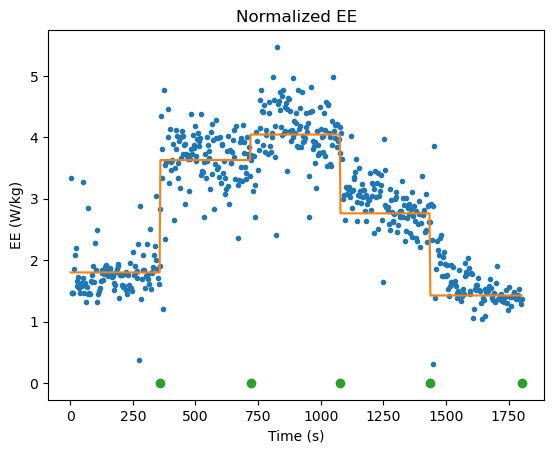

In [4]:
# plotting the EE results
# this is what we are trying to recreate with the wearable sensor data

plt.plot(result['Subject01']['Walking']['Metabolics_System']['Data'][:,time], EE, '.', label='EE')
plt.plot(result['Subject01']['Walking']['Metabolics_System']['Data'][:,time], EE_ground, '-', label='EE_ground')
plt.plot(result['Subject01']['Walking']['Metabolics_System']['Data'][indShift,time], np.zeros(np.size(indShift)), 'o', label='ind')
plt.ylabel('EE (W/kg)')
plt.xlabel('Time (s)')
plt.title('Normalized EE')
plt.show()

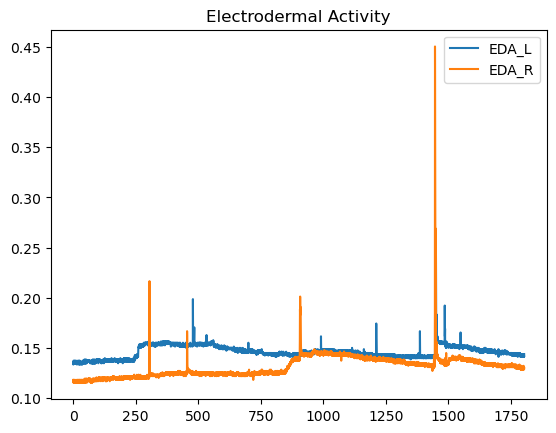

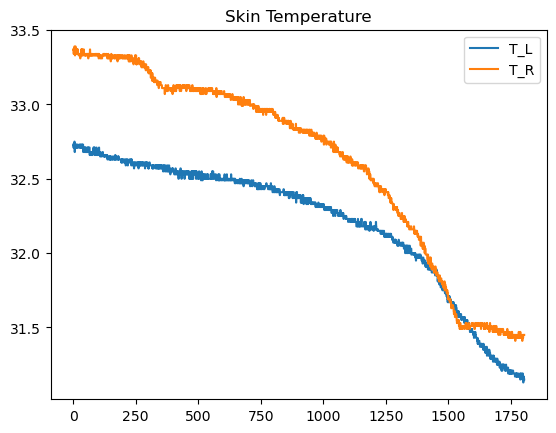

In [5]:
# starting off with some plotting for data exploration

plt.plot(df1['Subject01']['Walking']['Empatica_Physio']['Data'][:,time],df1['Subject01']['Walking']['Empatica_Physio']['Data'][:,2], label='EDA_L')
plt.plot(df1['Subject01']['Walking']['Empatica_Physio']['Data'][:,time],df1['Subject01']['Walking']['Empatica_Physio']['Data'][:,4], label='EDA_R')
plt.legend()
plt.title("Electrodermal Activity")
plt.show()

plt.plot(df1['Subject01']['Walking']['Empatica_Physio']['Data'][:,time],df1['Subject01']['Walking']['Empatica_Physio']['Data'][:,3], label='T_L')
plt.plot(df1['Subject01']['Walking']['Empatica_Physio']['Data'][:,time],df1['Subject01']['Walking']['Empatica_Physio']['Data'][:,5], label='T_R')
plt.legend()
plt.title("Skin Temperature")
plt.show()


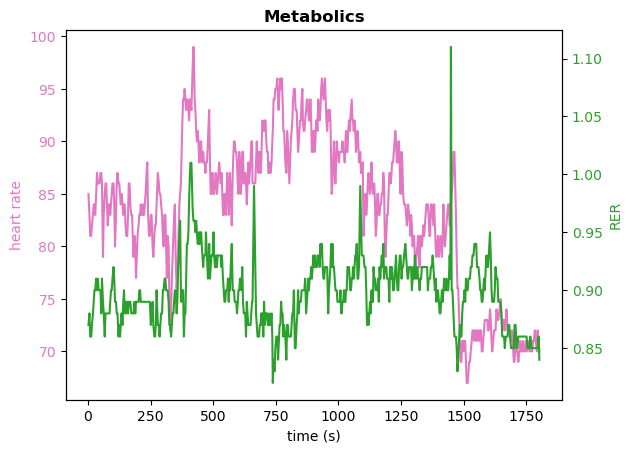

In [6]:
# plotting two things at once to see relationships with respect to time
fig, ax1 = plt.subplots() 
 
color = 'tab:pink'
ax1.set_xlabel('time (s)') 
ax1.set_ylabel('heart rate', color = color) 
ax1.plot(df1['Subject01']['Walking']['Metabolics_System']['Data'][:,time], df1['Subject01']['Walking']['Metabolics_System']['Data'][:,hr], color = color) 
ax1.tick_params(axis ='y', labelcolor = color) 
 
# Adding Twin Axes to plot using dataset_2
ax2 = ax1.twinx() 
 
color = 'tab:green'
ax2.set_ylabel('RER', color = color) 
ax2.plot(df1['Subject01']['Walking']['Metabolics_System']['Data'][:,time], df1['Subject01']['Walking']['Metabolics_System']['Data'][:,rer], color = color) 
ax2.tick_params(axis ='y', labelcolor = color) 
 
# Adding title
plt.title('Metabolics', fontweight ="bold") 
 
# Show plot
plt.show()



In [7]:
# correlations
# different data sources have different sampling frequencies so need to find common points in time
Tinter, Empind, EEind = np.intersect1d(result['Subject01']['Walking']['Empatica_Physio']['Data'][:,time], result['Subject01']['Walking']['Metabolics_System']['Data'][:,time], return_indices=True)
r = sp.stats.pearsonr(result['Subject01']['Walking']['Empatica_Physio']['Data'][Empind,4], EE_ground[EEind])
print(r)

PearsonRResult(statistic=0.031859362660606544, pvalue=0.44656223830549807)


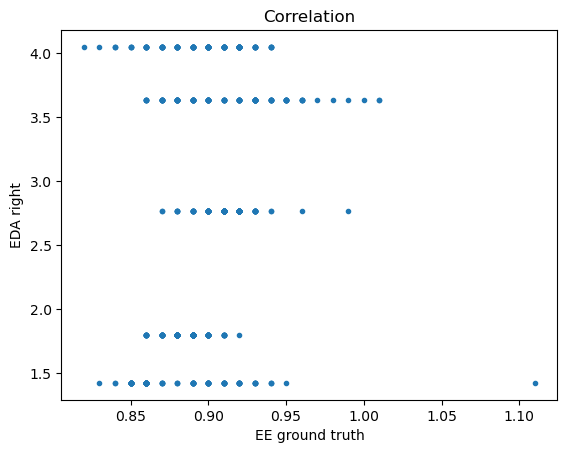

In [8]:
# plotting correlations
plt.plot(result['Subject01']['Walking']['Metabolics_System']['Data'][:,rer], EE_ground[EEind], '.')
plt.title("Correlation")
plt.xlabel("EE ground truth")
plt.ylabel("EDA right")
plt.show()

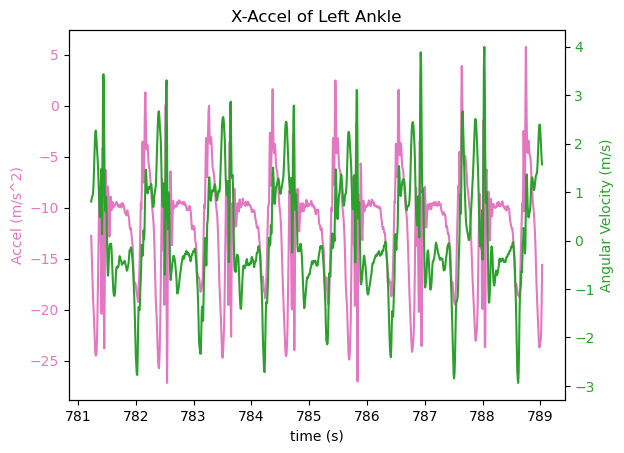

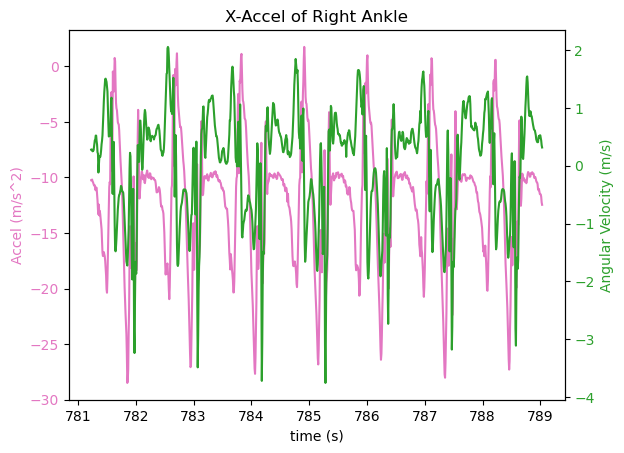

In [9]:
fig, ax1 = plt.subplots() 

color = 'tab:pink'
ax1.set_xlabel('time (s)') 
ax1.set_ylabel('Accel (m/s^2)', color = color) 
ax1.plot(result['Subject01']['Walking']['APDM_Accel']['Data'][100000:101000,time],result['Subject01']['Walking']['APDM_Accel']['Data'][100000:101000,20], color = color)
ax1.tick_params(axis ='y', labelcolor = color) 
 
# Adding Twin Axes to plot using dataset_2
ax2 = ax1.twinx() 
 
color = 'tab:green'
ax2.set_ylabel('Angular Velocity (m/s)', color = color) 
ax2.plot(result['Subject01']['Walking']['APDM_Accel']['Data'][100000:101000,time],result['Subject01']['Walking']['APDM_Accel']['Data'][100000:101000,23], color = color)
ax2.tick_params(axis ='y', labelcolor = color) 


plt.xlabel('time (s)')
plt.title('X-Accel of Left Ankle')
plt.show()

fig, ax1 = plt.subplots() 

color = 'tab:pink'
ax1.set_xlabel('time (s)') 
ax1.set_ylabel('Accel (m/s^2)', color = color) 
ax1.plot(result['Subject01']['Walking']['APDM_Accel']['Data'][100000:101000,time],result['Subject01']['Walking']['APDM_Accel']['Data'][100000:101000,29], color = color)
ax1.tick_params(axis ='y', labelcolor = color) 
 
# Adding Twin Axes to plot using dataset_2
ax2 = ax1.twinx() 
 
color = 'tab:green'
ax2.set_ylabel('Angular Velocity (m/s)', color = color) 
ax2.plot(result['Subject01']['Walking']['APDM_Accel']['Data'][100000:101000,time],result['Subject01']['Walking']['APDM_Accel']['Data'][100000:101000,32], color = color)
ax2.tick_params(axis ='y', labelcolor = color) 


plt.xlabel('time (s)')
plt.title('X-Accel of Right Ankle')
plt.show()

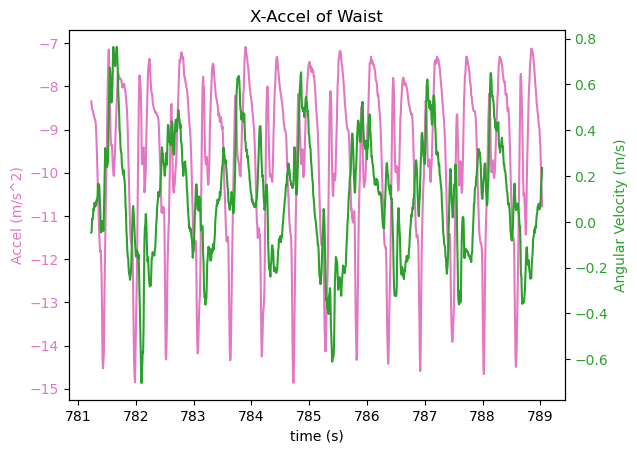

In [10]:
fig, ax1 = plt.subplots() 

color = 'tab:pink'
ax1.set_xlabel('time (s)') 
ax1.set_ylabel('Accel (m/s^2)', color = color) 
ax1.plot(result['Subject01']['Walking']['APDM_Accel']['Data'][100000:101000,time],result['Subject01']['Walking']['APDM_Accel']['Data'][100000:101000,2], color = color)
ax1.tick_params(axis ='y', labelcolor = color) 
 
# Adding Twin Axes to plot using dataset_2
ax2 = ax1.twinx() 
 
color = 'tab:green'
ax2.set_ylabel('Angular Velocity (m/s)', color = color) 
ax2.plot(result['Subject01']['Walking']['APDM_Accel']['Data'][100000:101000,time],result['Subject01']['Walking']['APDM_Accel']['Data'][100000:101000,5], color = color)
ax2.tick_params(axis ='y', labelcolor = color) 


plt.xlabel('time (s)')
plt.title('X-Accel of Waist')
plt.show()

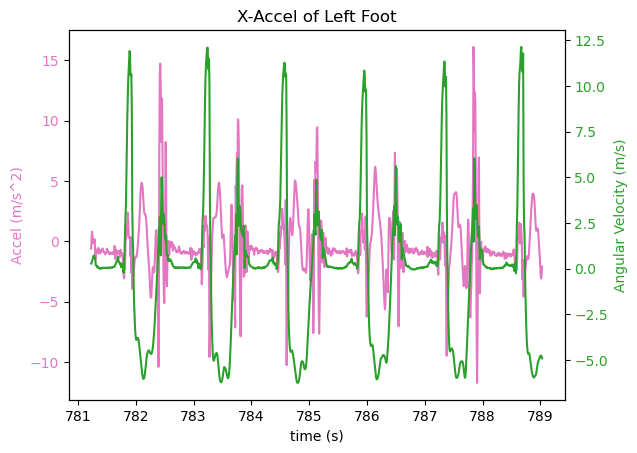

In [11]:

fig, ax1 = plt.subplots() 

color = 'tab:pink'
ax1.set_xlabel('time (s)') 
ax1.set_ylabel('Accel (m/s^2)', color = color)
ax1.plot(result['Subject06']['Walking']['APDM_Accel']['Data'][100000:101000,time],result['Subject06']['Walking']['APDM_Accel']['Data'][100000:101000,39], color = color)
ax1.tick_params(axis ='y', labelcolor = color) 
 
# Adding Twin Axes to plot using dataset_2
ax2 = ax1.twinx() 
 
color = 'tab:green'
ax2.set_ylabel('Angular Velocity (m/s)', color = color) 
ax2.plot(result['Subject06']['Walking']['APDM_Accel']['Data'][100000:101000,time],result['Subject06']['Walking']['APDM_Accel']['Data'][100000:101000,42], color = color)
ax2.tick_params(axis ='y', labelcolor = color) 

plt.xlabel('time (s)')
plt.title('X-Accel of Left Foot')
plt.show()